<h1><center>Introduction to K-Nearest Neighbors (KNN)</center></h1>

<h4>Have you ever asked a group of friends for advice and followed what most of them suggested?</h4>

<h3>➡️ Explain:</h3>
<h4>Just like we make decisions based on what is most common among our peers, the K-Nearest Neighbors (KNN) algorithm makes predictions by looking at the nearest data points. It classifies a new data point based on the majority category of its closest neighbors or predicts a numerical value based on the average of its neighbors.</h4>

<h3>🖥️ Definition:</h3>
<h4>K-Nearest Neighbors (KNN) is a non-parametric, instance-based Machine Learning algorithm that makes predictions by finding the ‘K’ most similar data points (neighbors) in the training dataset.</h4>

<h3>📝 Key Characteristics:</h3>
<h4>It is a lazy learning algorithm, meaning it stores the training data and makes predictions only when needed.<br>
It is distance-based; similar data points are closer in feature space.<br>
The value of ‘K’ determines how many neighbors influence the prediction.</h4>

<h1><center>KNN for Classification vs. Regression</center></h1>
<h4>KNN can be used for both Classification and Regression tasks.</h4>

<h3>A. KNN for Classification</h3>
<h4>If I show you a fruit and ask whether it’s an apple or an orange, how will you decide?</h4>

<h3>➡️ Explain:</h3>
<h4>You will compare it to the closest fruits you’ve seen before and classify it based on the majority category. KNN does the same by looking at the ‘K’ nearest points and assigning the most common label.</h4>

<h3>🖥️ Definition:</h3>
<h4>In KNN Classification, a data point is classified based on the majority label among its K-nearest neighbors.</h4>

<h3>📌 Examples of KNN Classification:</h3>
<h4>Email Spam Detection → Classify as Spam or Not Spam <br>
Handwriting Recognition → Classify digits (0 to 9) <br>
Medical Diagnosis → Classify a disease based on symptoms <br>
Customer Segmentation → Group customers based on behavior <br>
Iris Flower Classification → Classify a flower species</h4>

<h3>B. KNN for Regression</h3>
<h4>If I ask you to predict the price of a house based on similar houses in the area, what will you do?</h4>

<h3>➡️ Explain:</h3>
<h4>You will look at the prices of nearby houses and take the average or weighted average. KNN Regression does the same by predicting a continuous value based on the values of its K-nearest neighbors.</h4>

<h3>🖥️ Definition:</h3>
<h4>In KNN Regression, the output is a numerical value calculated as the average (or weighted average) of the K-nearest neighbors.</h4>

<h3>📌 Examples of KNN Regression:</h3>
<h4>House Price Prediction → Predict price based on nearby houses <br>
Weather Forecasting → Predict temperature based on past data <br>
Stock Market Prediction → Predict stock prices based on trends <br>
Movie Rating Prediction → Predict a movie rating based on similar movies <br>
Sales Forecasting → Predict future sales based on previous data</h4>

<h1><center>Key Concepts of KNN</center></h1>

<h3>🔹 Choosing the Right ‘K’ Value</h3>
<h4>The value of ‘K’ determines how many neighbors influence the prediction.<br>
A small K may lead to noise affecting predictions, while a large K may generalize too much.<br>
An optimal K is often chosen using cross-validation.</h4>

<h3>🔹 Distance Metrics</h3>
<h4>KNN relies on distance to find the nearest neighbors.<br>
Common distance metrics include:<br>
✔️ Euclidean Distance (most commonly used) <br>
✔️ Manhattan Distance <br>
✔️ Minkowski Distance <br>
✔️ Cosine Similarity (for text data)</h4>

<h3>🔹 Advantages of KNN</h3>
<h4>Simple to understand and implement.<br>
Works well with small to medium-sized datasets.<br>
Can be used for both classification and regression.</h4>

<h3>🔹 Disadvantages of KNN</h3>
<h4>Slow for large datasets as it requires calculating distances for all data points.<br>
Sensitive to irrelevant or redundant features.<br>
Performance depends on the choice of ‘K’ and distance metric.</h4>

<h1><center>Quick Summary of KNN</center></h1>

<h4>✔️ KNN is a simple yet powerful supervised learning algorithm.<br>
✔️ It classifies or predicts based on the nearest K neighbors.<br>
✔️ Works well for classification and regression.<br>
✔️ Performance depends on the choice of ‘K’ and distance metric.<br>
✔️ Best suited for smaller datasets due to its computational cost.</h4>


<h1><center>Training a KNN Model</center></h1>

# 📌 Step 1: Importing Required Libraries

In [3]:
import numpy as np
import pandas as pd

# 📌 Step 2: Loading the Dataset

In [7]:
df = pd.read_csv('diabetes.csv')
print(df.head())
print(df.info())

df.head()

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# 📌 Step 3: Splitting Features (X) and Target (y)

In [14]:
x = df.drop('Outcome',axis=1)
y = df['Outcome']
print(x.shape,y.shape)

(768, 8) (768,)


# 📌 Step 4: Splitting Data into Training & Testing Sets

In [15]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(614, 8) (154, 8) (614,) (154,)


# 📌 Step 5: Initializing & Training the KNN Model

In [10]:
from sklearn.neighbors import KNeighborsClassifier

from sklearn import metrics

for i in range(1,15):
    
    model = KNeighborsClassifier(n_neighbors = i)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    print(f"Accuracy Score: with {i} id {metrics.accuracy_score(y_test,y_pred)}")
    

Accuracy Score: with 1 id 0.6753246753246753
Accuracy Score: with 2 id 0.7012987012987013
Accuracy Score: with 3 id 0.6493506493506493
Accuracy Score: with 4 id 0.7077922077922078
Accuracy Score: with 5 id 0.6623376623376623
Accuracy Score: with 6 id 0.7272727272727273
Accuracy Score: with 7 id 0.6883116883116883
Accuracy Score: with 8 id 0.7467532467532467
Accuracy Score: with 9 id 0.7207792207792207
Accuracy Score: with 10 id 0.7662337662337663
Accuracy Score: with 11 id 0.7337662337662337
Accuracy Score: with 12 id 0.7792207792207793
Accuracy Score: with 13 id 0.7727272727272727
Accuracy Score: with 14 id 0.7727272727272727


C:\Users\vidhu\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\vidhu\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

In [11]:
model = KNeighborsClassifier(n_neighbors = 12)

model.fit(x_train,y_train)


KNeighborsClassifier(n_neighbors=12)

In [12]:
y_pred = model.predict(x_test)
compare = pd.DataFrame({"Actual:":y_test,"Predicted:":y_pred})
print(compare)


     Actual:  Predicted:
668        0           0
324        0           0
624        0           0
690        0           0
473        0           0
..       ...         ...
355        1           1
534        0           0
344        0           0
296        1           0
462        0           0

[154 rows x 2 columns]


C:\Users\vidhu\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


# 📌 Step 6: Making Predictions

In [ ]:
True Positive ---> Actual Yes , Model Yes   ***
True Negative ---> Actual Yes, Model No
False Positive ---> Actual No, Model Yes
False Negative ---> Actual No, Model No     ***

# 📌 Step 7: Evaluating the Model

# 📌 Step 8: Plotting Accuracy vs. k

# 📌 Step 9: Confusion Matrix

In [18]:
from sklearn import metrics

cm = metrics.confusion_matrix(y_test,y_pred)
print("Confusion Matrix: \n",cm)

# 89(Actual True & Predicted True)     10 (Actual False & Predicted True)
# 24(Actual True & Predicted Fale)     31 (aCTUAL fALSE & pREDICTED fALSE)
# 89 & 31


Confusion Matrix: 
 [[89 10]
 [24 31]]


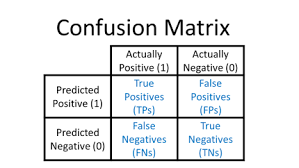

# 📌 Step 10: Visualizing Confusion Matrix

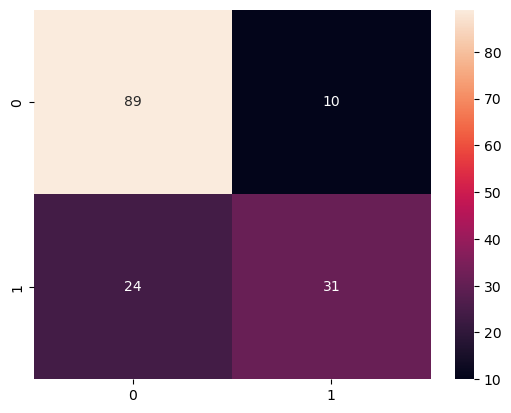

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm,annot=True)
plt.show()

In [ ]:
x1,y1
x2,y2

root((x2-x1)^2 + (y2-y1)^2)